In [300]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker

# Parabola

In [301]:
flat_source, flat_target, hl, f1, L, f2 = np.loadtxt('datafinpara/input.csv', delimiter = ',')
print(f"flat source = {bool(flat_source)}, flat target = {bool(flat_target)}, half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}")

flat source = True, flat target = True, half-length = 0.001, f1 = 1.0, L = 4.0, f2 = 2.0


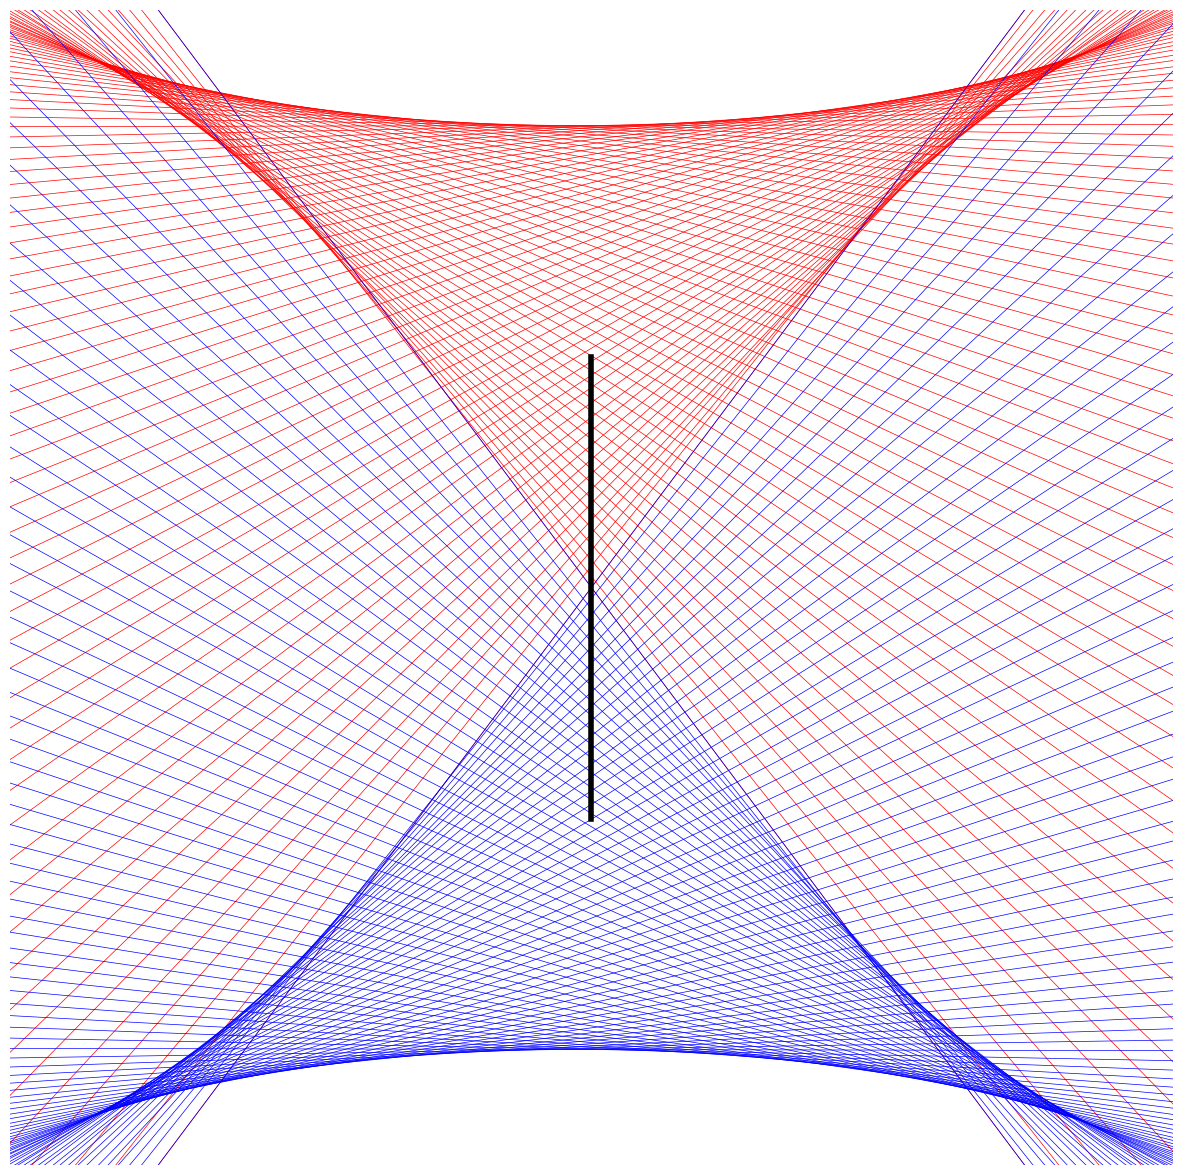

In [304]:
fig, ax = plt.subplots(1, figsize = (15, 15))

extrdiff1 = np.loadtxt('datafinpara/extrdiff1.csv', delimiter = ',')
extrdiff2 = np.loadtxt('datafinpara/extrdiff2.csv', delimiter = ',')
for row in extrdiff1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extrdiff2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')

if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl / np.pi, color = 'lightgrey', label = 'target'))
elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif not flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl, color = 'lightgrey', label = 'target'))

Y = np.linspace(-5, 5, 100)
M1X = 1 / (4 * f1) * (Y ** 2) - L - f1
ax.scatter(M1X, Y, s = 10, c = 'blue', label = 'parabola 1')
M2X = -1 / (4 * f2) * (Y ** 2) + f2
ax.scatter(M2X, Y, s = 10, c = 'purple', label = 'parabola 2')

plt.axis('equal')
zoom = hl * 2.5 # 2, 20
plt.axis([-zoom, zoom, -zoom, zoom])
# plt.axis([-f1 - L - 2, f2 + 2, -5, 5])
plt.axis('off')
plt.show()

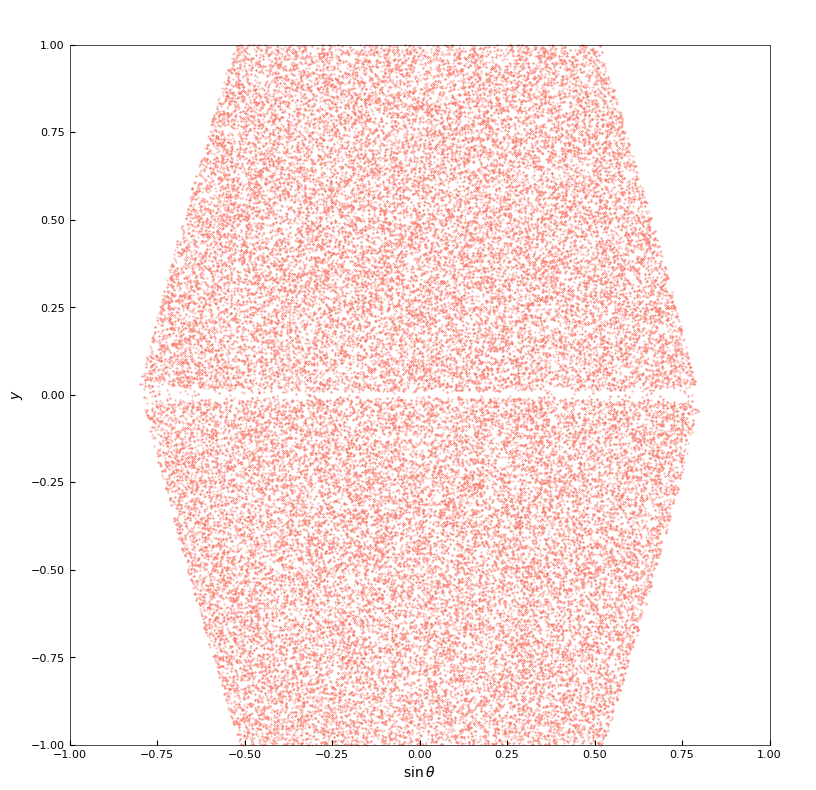

In [303]:
# flat target
fig, ax = plt.subplots(1, figsize = (10, 10))
ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 8)
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((-1, 1))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', -1))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((-1, 1))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', 1))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)

phase = np.loadtxt('datafinpara/phase.csv', delimiter = ',')
max = np.max(phase[:, 1])
ax.scatter(phase[:, 0], phase[:, 1] / max, s = 0.1, c = 'salmon')

ax.set_xlabel(r"$\sin\theta$")
ax.set_ylabel(r"$y$")
plt.axis('equal')
plt.show()